In [1]:
pip install pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


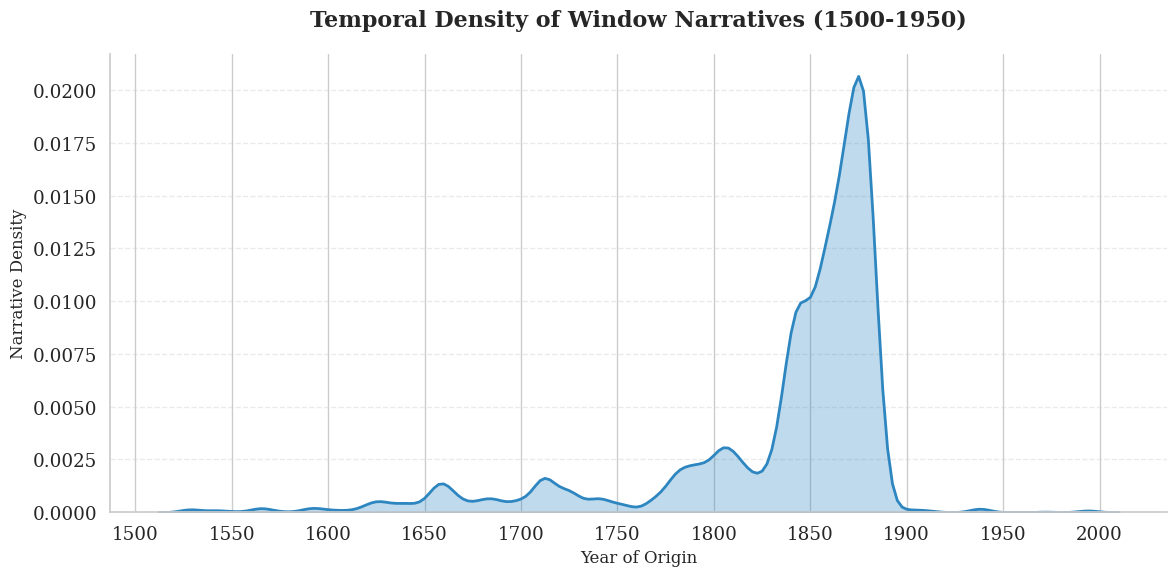

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# ===== Step 1: Load Data =====
file_path = "windows_activity_svo_final.csv"
df = pd.read_csv(file_path)

# ===== Step 2: Data Cleaning - Extract Year Numbers =====
def extract_year(year_str):
    """Extract 4-digit year from string using regex"""
    # Use regex to match 4-digit numbers
    match = re.search(r'\d{4}', str(year_str))
    return int(match.group()) if match else None

df['year_int'] = df['year'].apply(extract_year)
# Remove rows where year cannot be extracted
df_clean = df.dropna(subset=['year_int'])

# ===== Step 3: Set Plot Style (Publication-Quality Appearance) =====
plt.rcParams['font.family'] = 'serif'  # Use serif font
sns.set_context("notebook", font_scale=1.2)
plt.figure(figsize=(12, 6), facecolor='white')

# ===== Step 4: Create Kernel Density Estimation Plot (KDE Plot) =====
# bw_adjust controls smoothness: smaller values are more sensitive, capturing subtle historical patterns
sns.kdeplot(
    data=df_clean, 
    x='year_int', 
    fill=True, 
    color="#2E86C1", 
    alpha=0.3, 
    linewidth=2, 
    bw_adjust=0.4
)

# ===== Step 5: Polish Details =====
plt.title('Temporal Density of Window Narratives (1500-1950)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Year of Origin', fontsize=12)
plt.ylabel('Narrative Density', fontsize=12)

# Set x-axis range and intervals for better readability
plt.xticks(range(1500, 2001, 50))
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Remove top and right borders for cleaner appearance
sns.despine()

# ===== Step 6: Save and Display =====
plt.tight_layout()
plt.savefig('temporal_density_analysis.png', dpi=300)
plt.show()

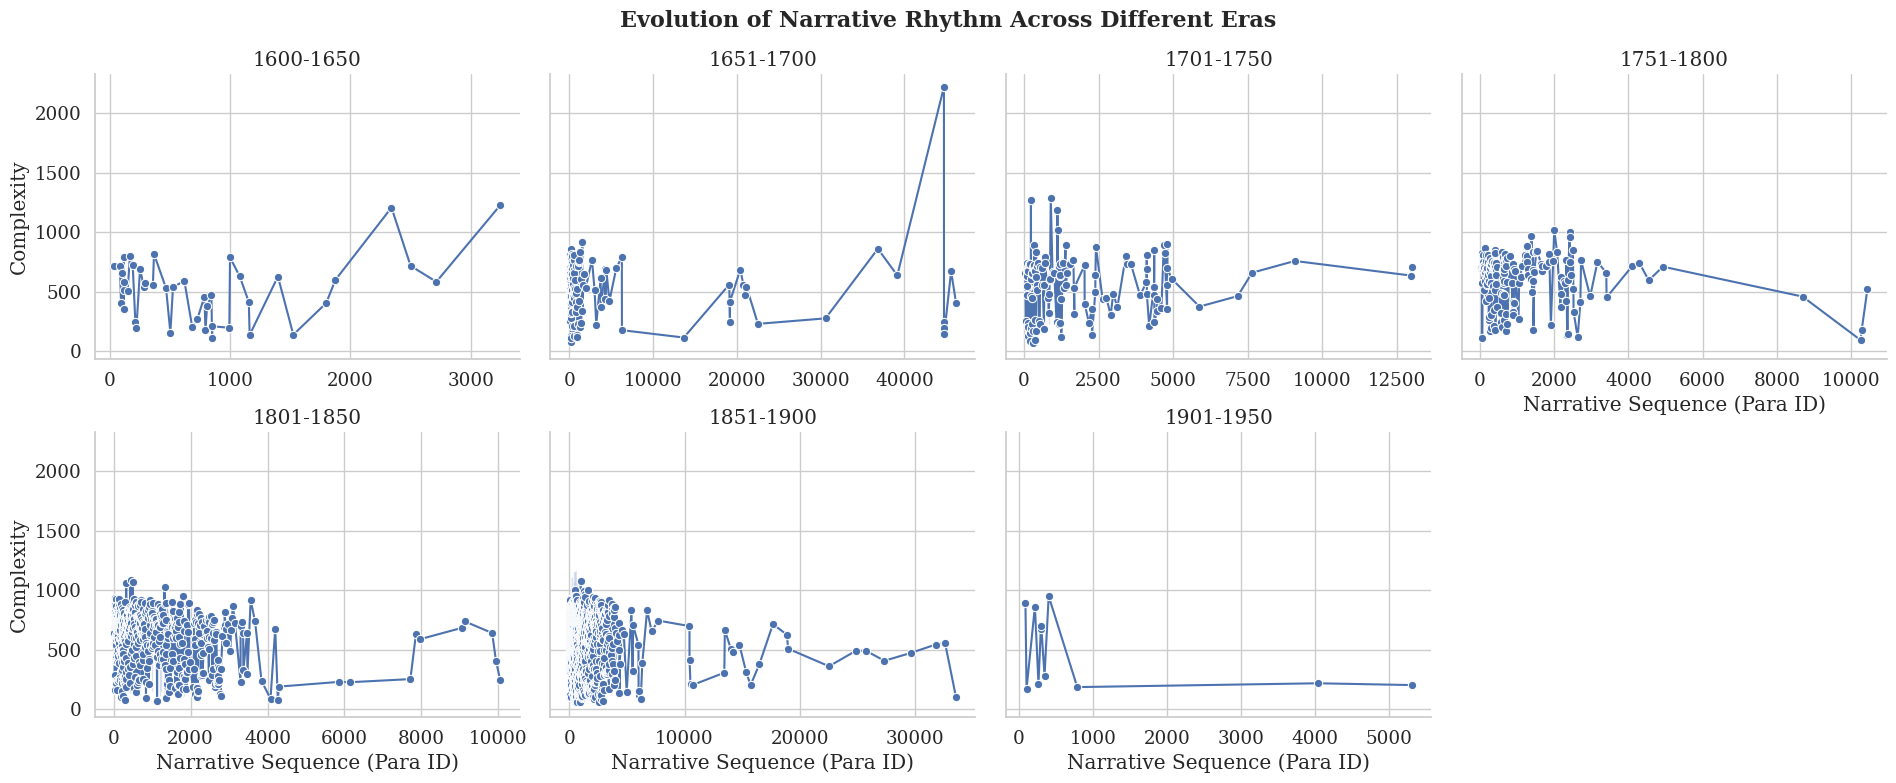

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

# ===== Step 1: Data Cleaning =====
file_path = "windows_activity_svo_final.csv"
df = pd.read_csv(file_path)

def extract_year(y):
    """Extract 4-digit year from string"""
    m = re.search(r'\d{4}', str(y))
    return int(m.group()) if m else None

df['Year_Clean'] = df['year'].apply(extract_year)
df['Complexity'] = df['text_en'].str.len()
df = df.dropna(subset=['Year_Clean'])

# ===== Step 2: CORE STEP - Temporal Binning =====
# We divide the 1600-1950 period into stages of 50 years each
bins = [1600, 1650, 1700, 1750, 1800, 1850, 1900, 1950]
labels = ['1600-1650', '1651-1700', '1701-1750', '1751-1800', '1801-1850', '1851-1900', '1901-1950']
df['Period'] = pd.cut(df['Year_Clean'], bins=bins, labels=labels)

# ===== Step 3: Use Seaborn FacetGrid Template =====
# col="Period" creates subplots by time period, col_wrap=4 displays 4 plots per row
plt.rcParams['font.family'] = 'serif'
g = sns.relplot(
    data=df,
    x="para_id", y="Complexity", 
    col="Period", col_wrap=4,
    kind="line", marker="o",  # Line plot with markers: like an EKG showing narrative rhythm
    height=4, aspect=1.2,
    facet_kws={'sharex': False, 'sharey': True} # Unified Y-axis for intensity comparison, independent X-axis
)

# ===== Step 4: Polish Details =====
g.set_axis_labels("Narrative Sequence (Para ID)", "Complexity")
g.set_titles("{col_name}")
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Evolution of Narrative Rhythm Across Different Eras', fontsize=16, fontweight='bold')

plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ===== Step 1: Read and Clean Column Headers =====
file_path = r"C:\Users\asus\Desktop\RC11 TERM2\windows_activity_svo_final.csv"
df = pd.read_csv(file_path)
df.columns = df.columns.str.strip()  # Remove leading/trailing spaces from column names to fix KeyError

# ===== Step 2: Data Preprocessing - Split Comma-Separated Strings and "Explode" =====
def clean_and_explode(df, column):
    """Convert comma-separated strings to list and expand each element to separate row"""
    # Convert to string, split by comma, remove spaces
    s = df[column].astype(str).str.split(', ')
    return s.explode().str.strip()

# Extract and filter out common stopwords
stopwords = {'i', 'he', 'she', 'it', 'they', 'we', 'who', 'what', 'none', 'nan', 'be', 'do'}

# Process subjects and verbs
subjects_cleaned = clean_and_explode(df, 'subject')
subjects_cleaned = subjects_cleaned[~subjects_cleaned.lower().isin(stopwords)]

verbs_cleaned = clean_and_explode(df, 'verb')
verbs_cleaned = verbs_cleaned[~verbs_cleaned.lower().isin(stopwords)]

# ===== Step 3: Plot Settings =====
sns.set_theme(style="whitegrid", font="serif")
plt.rcParams['axes.unicode_minus'] = False 

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Plot 1: Top 10 Subjects (after filtering pronouns) ---
top_subs = subjects_cleaned.value_counts().head(10)
sns.barplot(x=top_subs.values, y=top_subs.index, ax=axes[0, 0], palette="viridis")
axes[0, 0].set_title("Core Subjects (Pronouns Filtered)", fontsize=14, fontweight='bold')

# --- Plot 2: Historical Trend (optimized x-axis) ---
# Ensure years are numeric and remove outliers
df['year_clean'] = pd.to_numeric(df['year'], errors='coerce')
year_trends = df.groupby('year_clean').size()
sns.lineplot(x=year_trends.index, y=year_trends.values, marker='o', ax=axes[0, 1])
axes[0, 1].set_title("Activity Frequency Evolution Over Years", fontsize=14, fontweight='bold')
# If there are too many year values, limit x-axis tick density
axes[0, 1].set_xticks(axes[0, 1].get_xticks()[::5]) 

# --- Plot 3: Top 10 Verbs (after filtering) ---
top_vbs = verbs_cleaned.value_counts().head(10)
sns.barplot(x=top_vbs.values, y=top_vbs.index, ax=axes[1, 0], palette="magma")
axes[1, 0].set_title("Core Actions (Meaningful Verbs)", fontsize=14, fontweight='bold')

# --- Plot 4: Text Complexity Analysis ---
if 'matched_w' in df.columns:
    sns.boxenplot(x=df['matched_w'], ax=axes[1, 1], color='skyblue')
    axes[1, 1].set_title("Text Length Distribution (Boxenplot)", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

AttributeError: 'Series' object has no attribute 'lower'

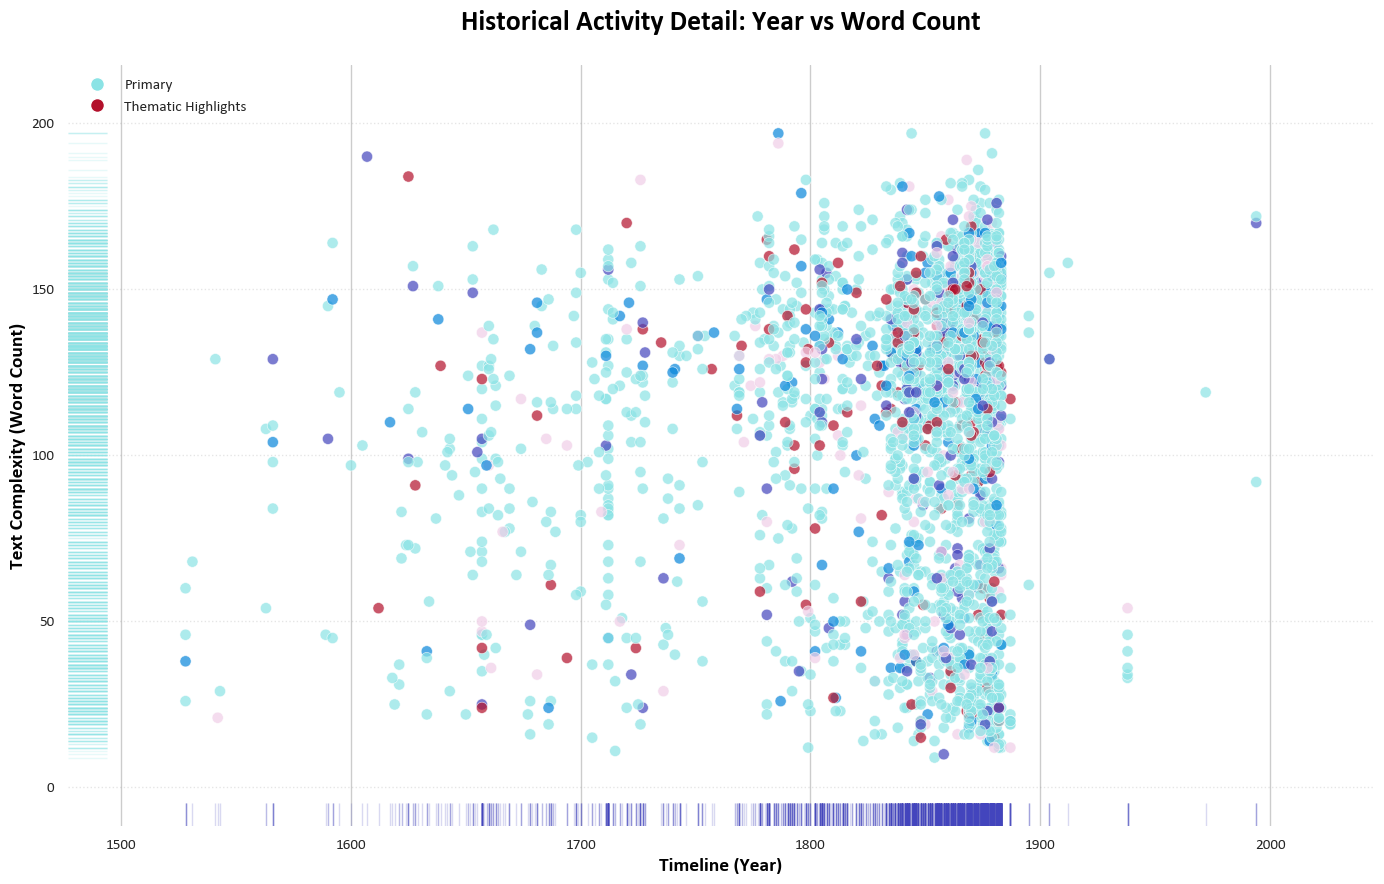

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.lines import Line2D

# ===== Step 1: Load and Clean Data =====
file_path = "windows_activity_svo_final.csv"
df = pd.read_csv(file_path, encoding='utf-8-sig')
df.columns = df.columns.str.strip().str.lower()

# ===== Step 2: Data Preprocessing =====
df['year_num'] = pd.to_numeric(df['year'], errors='coerce')
df['word_count'] = df['text_en'].astype(str).apply(lambda x: len(x.split()))
df['is_twin_city'] = df['text_en'].str.contains('twin|city', case=False, na=False)

# Filter and remove extreme outliers (Top 2%)
df_plot = df.dropna(subset=['year_num', 'word_count']).copy()
df_plot = df_plot[df_plot['word_count'] < df_plot['word_count'].quantile(0.98)]

# ===== Step 3: Color Logic =====
main_color = "#8be3e5" # Tiffany green
random_colors = ["#f0cee7", "#0987db", "#b3102b", "#4345bd"]

def assign_point_color(row):
    """Assign color based on Twin City relevance"""
    # Twin City-related records use random highlight colors
    if row['is_twin_city']:
        return np.random.choice(random_colors)
    else:
        # Regular records: 80% Tiffany green, 20% random accent for visual hierarchy
        return main_color if np.random.rand() > 0.2 else np.random.choice(random_colors)

np.random.seed(42)
df_plot['point_color'] = df_plot.apply(assign_point_color, axis=1)

# ===== Step 4: Global Font and Style Settings =====
plt.rcParams['font.sans-serif'] = ['Calibri', 'Arial', 'sans-serif'] # Prefer Calibri
plt.rcParams['font.family'] = 'sans-serif'

plt.figure(figsize=(14, 9))
plt.gcf().set_facecolor('white') # Pure white background
ax = plt.gca()
ax.set_facecolor('white')

# ===== Step 5: Create Scatter Plot =====
plt.scatter(
    df_plot['year_num'],
    df_plot['word_count'],
    c=df_plot['point_color'],
    s=65,
    alpha=0.7,
    edgecolors='white',
    linewidth=0.5
)

# Auxiliary density lines (Rugplot)
sns.rugplot(data=df_plot, x='year_num', color="#4345bd", alpha=0.2, height=0.03)
sns.rugplot(data=df_plot, y='word_count', color="#8be3e5", alpha=0.2, height=0.03)

# ===== Step 6: Chart Annotations and Formatting =====
plt.title("Historical Activity Detail: Year vs Word Count", 
          fontsize=20, pad=25, color="black", fontweight='bold')
plt.xlabel("Timeline (Year)", fontsize=14, color="black", fontweight='bold')
plt.ylabel("Text Complexity (Word Count)", fontsize=14, color="black", fontweight='bold')

# Update legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Primary', 
           markerfacecolor=main_color, markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Thematic Highlights', 
           markerfacecolor='#b3102b', markersize=10),
]
plt.legend(handles=legend_elements, loc='upper left', frameon=False, fontsize=11)

# Fine-tuning details
plt.grid(axis='y', color='gray', linestyle=':', alpha=0.2)
sns.despine(left=True, bottom=True) # Remove extra borders

plt.tight_layout()
plt.show()

C:\Users\asus\AppData\Local\Temp\ipykernel_6188\2300246171.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_subs.values, y=top_subs.index, ax=axes[0, 0], palette=sub_palette)
C:\Users\asus\AppData\Local\Temp\ipykernel_6188\2300246171.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_vbs.values, y=top_vbs.index, ax=axes[1, 0], palette=verb_palette)


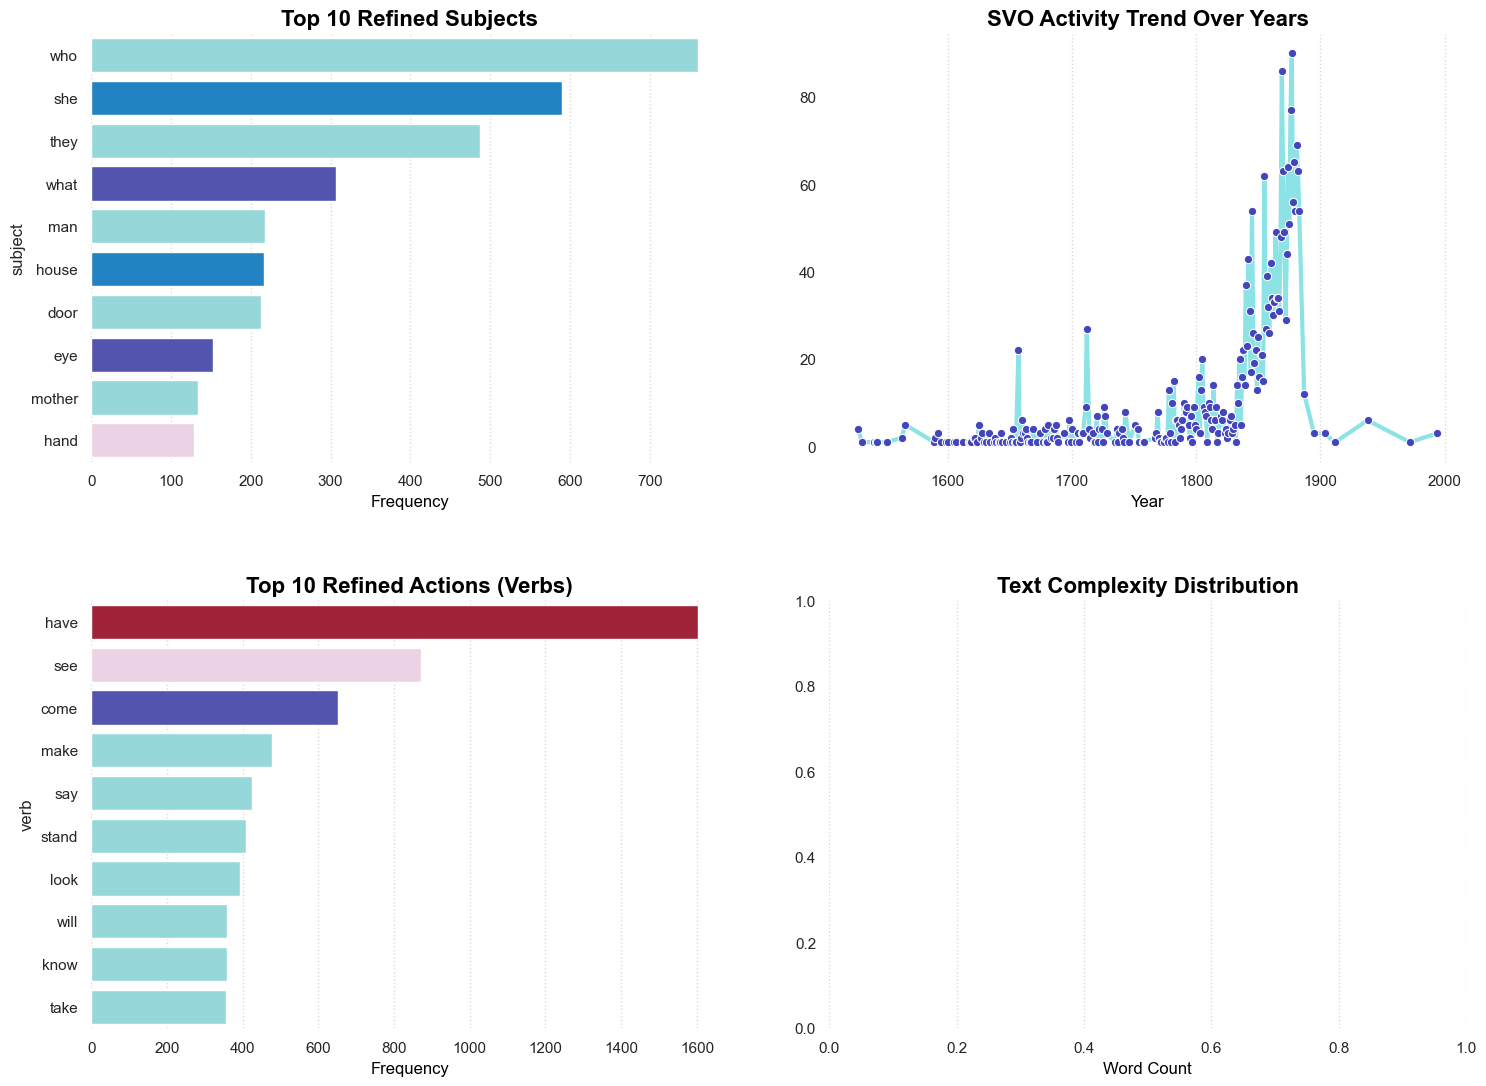

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re

# ===== Step 1: Load Data =====
file_path = r"C:\Users\asus\Desktop\RC11 TERM2\windows_activity_svo_final.csv"
df = pd.read_csv(file_path, encoding='utf-8-sig')
df.columns = df.columns.str.strip().str.lower()

# --- Auto-detect column names (prevent KeyError) ---
potential_cols = [c for c in df.columns if 'matched' in c and 'w' in c]
target_w_col = potential_cols[0] if potential_cols else None

# ===== Step 2: Advanced Cleaning Function =====
def advanced_clean(dataframe, column_name):
    """Advanced cleaning: split, explode, filter by regex"""
    s = dataframe[column_name].astype(str).str.split(', ')
    s = s.explode().str.strip().str.lower()
    # Filter: only letters, length > 2
    s = s[s.str.contains(r'^[a-z]{3,}$', na=False)]
    return s

# Blacklist filtering (includes redundant words related to previous "commodification" topic and common stop words)
blacklist = {'window', 'which', 'that', 'there', 'one', 'you', 'this', 
             'would', 'could', 'should', 'designation', 'none', 'the'}

subjects_cleaned = advanced_clean(df, 'subject')
subjects_cleaned = subjects_cleaned[~subjects_cleaned.isin(blacklist)]

verbs_cleaned = advanced_clean(df, 'verb')
verbs_cleaned = verbs_cleaned[~verbs_cleaned.isin(blacklist)]

# ===== Step 3: Global Style Settings (Calibri Font) =====
plt.rcParams['font.sans-serif'] = ['Calibri', 'Arial', 'sans-serif']
plt.rcParams['font.family'] = 'sans-serif'
sns.set_theme(style="white")

# Color definitions
main_color = "#8be3e5" # Tiffany green
accent_colors = ["#f0cee7", "#0987db", "#b3102b", "#4345bd"]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor('white')

# ===== Step 4: Plot 1 - Top 10 Subjects (Tiffany Green Gradient) =====
top_subs = subjects_cleaned.value_counts().head(10)
# Create a palette with Tiffany green as primary color
sub_palette = [main_color if i % 2 == 0 else np.random.choice(accent_colors) for i in range(10)]
sns.barplot(x=top_subs.values, y=top_subs.index, ax=axes[0, 0], palette=sub_palette)
axes[0, 0].set_title("Top 10 Refined Subjects", fontsize=16, fontweight='bold', color='black')
axes[0, 0].set_xlabel("Frequency", color='black')

# ===== Step 5: Plot 2 - Trend Over Years (Tiffany Green Thick Line) =====
df['year_numeric'] = pd.to_numeric(df['year'], errors='coerce')
year_trends = df.groupby('year_numeric').size()
sns.lineplot(x=year_trends.index, y=year_trends.values, ax=axes[0, 1], 
             color=main_color, linewidth=3, marker='o', markerfacecolor="#4345bd")
axes[0, 1].set_title("SVO Activity Trend Over Years", fontsize=16, fontweight='bold', color='black')
axes[0, 1].set_xlabel("Year", color='black')

# ===== Step 6: Plot 3 - Top 10 Actions (Random Accent Colors) =====
top_vbs = verbs_cleaned.value_counts().head(10)
verb_palette = [np.random.choice(accent_colors) if i < 3 else main_color for i in range(10)]
sns.barplot(x=top_vbs.values, y=top_vbs.index, ax=axes[1, 0], palette=verb_palette)
axes[1, 0].set_title("Top 10 Refined Actions (Verbs)", fontsize=16, fontweight='bold', color='black')
axes[1, 0].set_xlabel("Frequency", color='black')

# ===== Step 7: Plot 4 - Text Complexity Distribution =====
if target_w_col:
    df[target_w_col] = pd.to_numeric(df[target_w_col], errors='coerce')
    sns.histplot(df[target_w_col].dropna(), bins=30, ax=axes[1, 1], 
                 color=main_color, kde=True, line_kws={'color': '#b3102b'})
    axes[1, 1].set_title("Text Complexity Distribution", fontsize=16, fontweight='bold', color='black')
    axes[1, 1].set_xlabel("Word Count", color='black')

# ===== Step 8: Fine Tuning Details =====
for ax in axes.flat:
    sns.despine(ax=ax, left=True, bottom=True)
    ax.grid(axis='x', color='gray', linestyle=':', alpha=0.3)

plt.tight_layout(pad=4.0)
plt.show()

Processing 1000+ images... please wait.


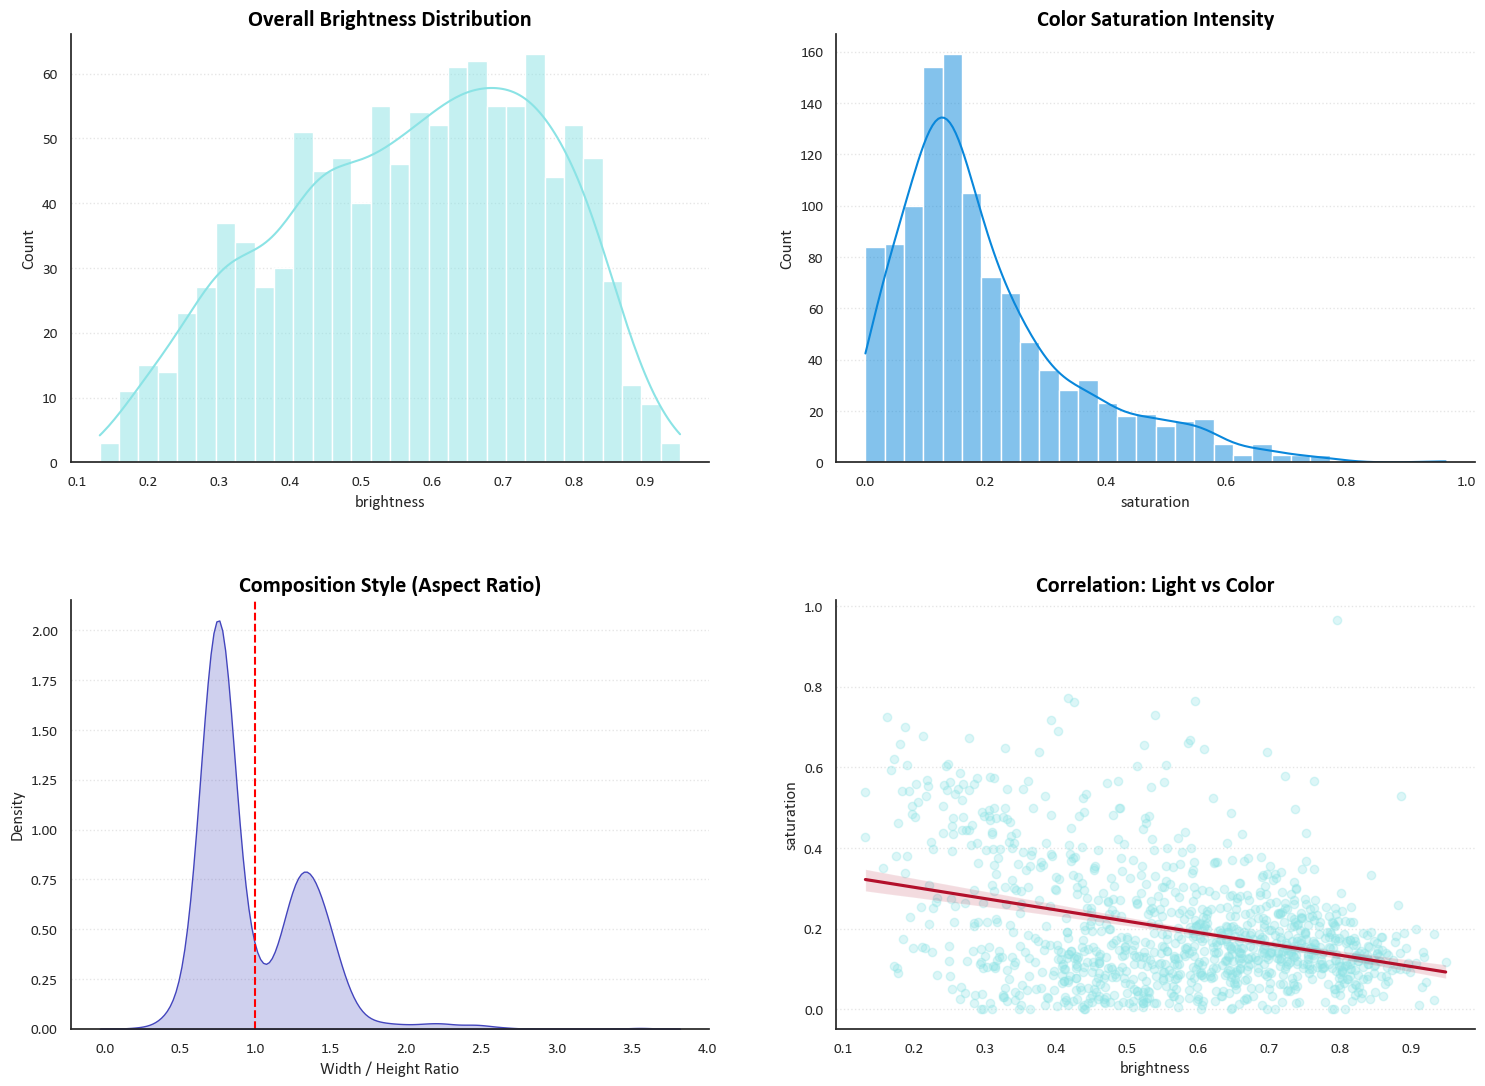

In [ ]:
import os
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from colorsys import rgb_to_hsv

# ===== Step 1: Set Image Folder Path =====
img_folder = r"C:\Users\asus\Desktop\RC11 TERM2\huazuo"

# ===== Step 2: Core Feature Extraction Logic (Generate Data Directly from JPG) =====
def analyze_images_locally(folder):
    """Extract visual features from all images in folder"""
    results = []
    print("Processing 1000+ images... please wait.")
    
    for filename in os.listdir(folder):
        if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
            path = os.path.join(folder, filename)
            try:
                with Image.open(path) as img:
                    width, height = img.size
                    aspect_ratio = width / height
                    
                    # Sample pixels to get color data
                    img_small = img.convert('RGB').resize((50, 50))
                    pixels = np.array(img_small) / 255.0
                    avg_rgb = pixels.mean(axis=(0, 1))
                    
                    # Convert to HSV (Hue, Saturation, Value/Brightness)
                    h, s, v = rgb_to_hsv(avg_rgb[0], avg_rgb[1], avg_rgb[2])
                    
                    results.append({
                        'aspect_ratio': aspect_ratio,
                        'brightness': v,
                        'saturation': s
                    })
            except: 
                continue
    return pd.DataFrame(results)

# Extract data
df_img = analyze_images_locally(img_folder)

# ===== Step 3: Style Settings (Calibri + Tiffany Green + Black Titles) =====
plt.rcParams['font.sans-serif'] = ['Calibri', 'Arial', 'sans-serif']
plt.rcParams['font.family'] = 'sans-serif'
main_color = "#8be3e5" # Tiffany green
accents = ["#f0cee7", "#0987db", "#b3102b", "#4345bd"]

# Create dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor('white')

# ===== Step 4: Plot 1 - Brightness Distribution =====
sns.histplot(df_img['brightness'], bins=30, kde=True, ax=axes[0, 0], color=main_color)
axes[0, 0].set_title("Overall Brightness Distribution", fontsize=16, fontweight='bold', color='black')

# ===== Step 5: Plot 2 - Saturation Distribution =====
sns.histplot(df_img['saturation'], bins=30, kde=True, ax=axes[0, 1], color=accents[1])
axes[0, 1].set_title("Color Saturation Intensity", fontsize=16, fontweight='bold', color='black')

# ===== Step 6: Plot 3 - Composition Ratio Analysis =====
# 1.0 represents square, >1 represents landscape, <1 represents portrait
sns.kdeplot(df_img['aspect_ratio'], fill=True, ax=axes[1, 0], color=accents[3])
axes[1, 0].axvline(1.0, color='red', linestyle='--') # Square boundary line
axes[1, 0].set_title("Composition Style (Aspect Ratio)", fontsize=16, fontweight='bold', color='black')
axes[1, 0].set_xlabel("Width / Height Ratio")

# ===== Step 7: Plot 4 - Brightness vs Saturation Regression =====
sns.regplot(x='brightness', y='saturation', data=df_img, ax=axes[1, 1], 
            scatter_kws={'alpha':0.3, 'color':main_color}, 
            line_kws={'color':accents[2]})
axes[1, 1].set_title("Correlation: Light vs Color", fontsize=16, fontweight='bold', color='black')

# ===== Step 8: Fine Tuning Details =====
for ax in axes.flat:
    sns.despine(ax=ax)
    ax.set_facecolor('white')
    ax.grid(axis='y', color='gray', linestyle=':', alpha=0.2)

plt.tight_layout(pad=4.0)
plt.show()